In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision.datasets import MNIST
from torch.utils.data import DataLoader
import torchvision.transforms as transforms

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

trainset = MNIST(root="./data", train=True, download=True, transform=transform)
testset = MNIST(root="./data", train=False, download=True, transform=transform)

trainloader = DataLoader(trainset, batch_size=64, shuffle=True)
testloader = DataLoader(testset, batch_size=64)

100%|██████████████████████████████████████| 9.91M/9.91M [00:05<00:00, 1.72MB/s]
100%|██████████████████████████████████████| 28.9k/28.9k [00:00<00:00, 69.8kB/s]
100%|███████████████████████████████████████| 1.65M/1.65M [00:03<00:00, 430kB/s]
100%|██████████████████████████████████████| 4.54k/4.54k [00:00<00:00, 3.10MB/s]


In [3]:
class CNN_MNIST(nn.Module):
    def __init__(self):
        super(CNN_MNIST, self).__init__()
        self.conv_layers = nn.Sequential(
            # Input channels changed from 3 to 1 for grayscale
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # 28x28 -> 14x14
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # 14x14 -> 7x7
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)  # 7x7 -> 3x3
        )
        
        self.fc_layers = nn.Sequential(
            # Flattened dimension changed: 3 * 3 * 128
            nn.Linear(3 * 3 * 128, 256),
            nn.ReLU(),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1) # flattening step
        x = self.fc_layers(x)
        return x

model = CNN_MNIST()

In [4]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())

In [5]:
epochs = 5 # MNIST is simpler, so 5 epochs is usually enough for high accuracy
for epoch in range(epochs):
    epoch_training_loss = 0.0
    for images, labels in trainloader:
        optimizer.zero_grad()
        output = model(images) 
        loss = criterion(output, labels)
        loss.backward()
        optimizer.step()
        epoch_training_loss += loss.item()
        
    print(f"epoch = {epoch + 1}/{epochs} & loss = {epoch_training_loss/len(trainloader):.4f}")


epoch = 1/5 & loss = 0.1517
epoch = 2/5 & loss = 0.0416
epoch = 3/5 & loss = 0.0304
epoch = 4/5 & loss = 0.0227
epoch = 5/5 & loss = 0.0182


In [6]:
correct_labels = 0
total_labels = 0
model.eval()

with torch.no_grad():
    for images, labels in testloader:
        output = model(images)
        _, predicted = torch.max(output, 1)
        correct_labels += (predicted == labels).sum().item()
        total_labels += labels.size(0)

print(f"accuracy = {(correct_labels / total_labels) * 100:.2f}%")

accuracy = 99.10%


<module 'matplotlib.pyplot' from '/opt/anaconda3/lib/python3.13/site-packages/matplotlib/pyplot.py'>

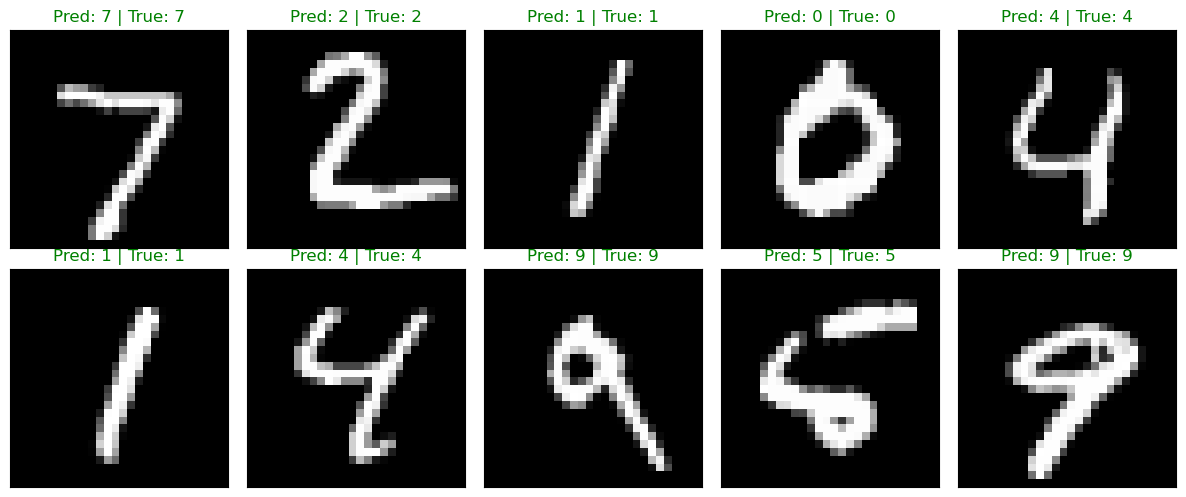

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import torch


dataiter = iter(testloader)
images, labels = next(dataiter)


model.eval() 
with torch.no_grad():
    outputs = model(images)
    _, predicted = torch.max(outputs, 1)


fig = plt.figure(figsize=(12, 5))

for idx in range(10):
    
    ax = fig.add_subplot(2, 5, idx+1, xticks=[], yticks=[])
    
    
    img = images[idx] / 2 + 0.5     
    npimg = img.numpy()
    
    
    plt.imshow(np.squeeze(npimg), cmap='gray')
    
   
    is_correct = predicted[idx] == labels[idx]
    color = 'green' if is_correct else 'red'
    
    ax.set_title(f"Pred: {predicted[idx].item()} | True: {labels[idx].item()}", color=color)

plt.tight_layout()
plt